# Part 1: Linear model

Pour la première deadline il faut rendre un fichier `y_pred.csv` qui sont les prédictions du modèle linéaire sur `X.csv` (dans *data/data_unlabeled/*)

1. Train/Validation Split
2. Baseline Model
3. Model Selection (tester plusieurs modèles)
4. Hyperparameter Tuning
5. Évaluation Finale sur Test Set
6. Prédictions sur Unlabeled Data

## Loading

In [111]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV, LassoLarsCV
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, GridSearchCV
from sklearn.metrics import mean_squared_error

import sys
sys.path.append('..')
from src.preprocessing import preprocess_pipeline, preprocess_pipeline_no_scaling

In [112]:
X_train = pd.read_csv('../data/data_labeled/X_train.csv')
y_train = pd.read_csv('../data/data_labeled/y_train.csv')
X_test = pd.read_csv('../data/data_labeled/X_test.csv')
y_test = pd.read_csv('../data/data_labeled/y_test.csv')

# Vérification des dimensions avant prétraitement
print("Dimensions avant prétraitement:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

# Aligner les données 
X_train = X_train.loc[y_train.index]
X_test = X_test.loc[y_test.index]

# preprocessing -> apres le split entre validation et train
#X_train_prep, scaler = preprocess_pipeline(X_train, fit_scaler=True)
#X_test_prep, _ = preprocess_pipeline(X_test, scaler=scaler, fit_scaler=False)

# Vérification des dimensions après prétraitement
print("\nDimensions après prétraitement et alignement:")
#print(f"X_train_prep: {X_train_prep.shape}")
print(f"y_train: {y_train.shape}")
#print(f"X_test_prep: {X_test_prep.shape}")
print(f"y_test: {y_test.shape}")

Dimensions avant prétraitement:
X_train: (1000, 14)
y_train: (999, 1)
X_test: (500, 14)
y_test: (499, 1)

Dimensions après prétraitement et alignement:
y_train: (999, 1)
y_test: (499, 1)


## 1. Train - validation split
### Questions
- Quelle proportion train/validation ? (80/20 ou 90/10)
### Réponses
- Plus on a données de validation meilleur sera notre estimation mais moins de données pour s'entrainer. Vu qu'on a environ 1000 données il faut prendre 80-20

In [113]:
TEST_SIZE = 0.2
RANDOM_STATE = 42
SHUFFLE = False

## 2. Baseline model

Il faut établir une référence, un modèle simple, basique par rapport auquel on va comparer les performances de notre modèle réel.
### Questions
- Lql choisir ?
- Doit-on faire déjà de la feature selection ?
- Sur quel data on évalue la baseline ?
- Quel metrics utiliser ? 

### Réponses
- Le plus basique : LinearRegression
- Pas encore, on utilise toutes les caractéristiques pour avoir un premier RMSE, avoir des données brut
- Entrainer sur X_train et évaluer sur X_val
- Les assistants ont dit qu'ils utiliseraient RMSE du coup la meme

Performance du modèle de base sur l'ensemble de validation:
validation RMSE: 0.0824

Performance sur l'ensemble d'entraînement (pour détecter l'overfitting):
train RMSE: 0.0801
CV RMSE per fold: [0.0735 0.0864 0.0887 0.0795 0.0715 0.0886 0.0945 0.0842 0.0797 0.0701]
CV RMSE mean: 0.08167291512095903 std: 0.007772957963539454


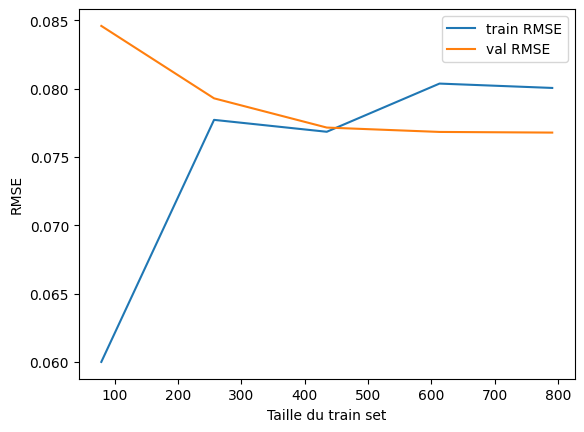

In [114]:
# Diviser les données en 80% de train - 20% de validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train.values.ravel(),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=SHUFFLE
)

# Prétraitement : fit du scaler sur le split d'entraînement puis application sur val/test
X_train_split_prep, scaler = preprocess_pipeline(X_train_split, fit_scaler=True)
X_val_split_prep, _ = preprocess_pipeline(X_val, scaler=scaler, fit_scaler=False)
X_test_prep, _ = preprocess_pipeline(X_test, scaler=scaler, fit_scaler=False)

# entrainement (ATTENTION : utiliser les données prétraitées)
baseline_model = LinearRegression()
baseline_model.fit(X_train_split_prep, y_train_split)

# Prédictions sur l'ensemble de validation
y_val_pred = baseline_model.predict(X_val_split_prep)
# Pour comparer, métrique sur l'ensemble d'entraînement
y_train_pred = baseline_model.predict(X_train_split_prep)

val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_rmse = np.sqrt(mean_squared_error(y_train_split, y_train_pred))

print("Performance du modèle de base sur l'ensemble de validation:")
print(f"validation RMSE: {val_rmse:.4f}")
print("\nPerformance sur l'ensemble d'entraînement (pour détecter l'overfitting):")
print(f"train RMSE: {train_rmse:.4f}")

# Cross-validation : s'assurer d'utiliser y_train_split (les labels du split), pas y_train complet
mse_scores = -cross_val_score(LinearRegression(),
                              X_train_split_prep,
                              y_train_split,
                              cv=10,
                              scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(mse_scores)
print("CV RMSE per fold:", np.round(rmse_scores,4))
print("CV RMSE mean:", rmse_scores.mean(), "std:", rmse_scores.std())

# Learning curve : éviter d'écraser val_rmse scalaire en renommant les sorties
train_sizes, train_scores_lc, val_scores_lc = learning_curve(LinearRegression(),
                                                       X_train_split_prep,
                                                       y_train_split,
                                                       cv=100,
                                                       scoring='neg_mean_squared_error',
                                                       train_sizes=np.linspace(0.1,1.0,5))
# Convertir MSE négatif en RMSE
train_rmse_lc = np.sqrt(-train_scores_lc)
val_rmse_lc = np.sqrt(-val_scores_lc)

plt.plot(train_sizes, train_rmse_lc.mean(axis=1), label='train RMSE')
plt.plot(train_sizes, val_rmse_lc.mean(axis=1), label='val RMSE')
plt.xlabel('Taille du train set')
plt.ylabel('RMSE')
plt.legend()
plt.show()

### Commentaires
Pas d'overfitting car le modèle ginéralise au moins auss bien que sur les données d'entrainement (différence de 0.0012).

Maintenant, tous nos modèles doivent faire bcp mieux que ca 

### Analyse du test size (pcq y a une legere différence quand on change le paramètres TEST_SIZE)

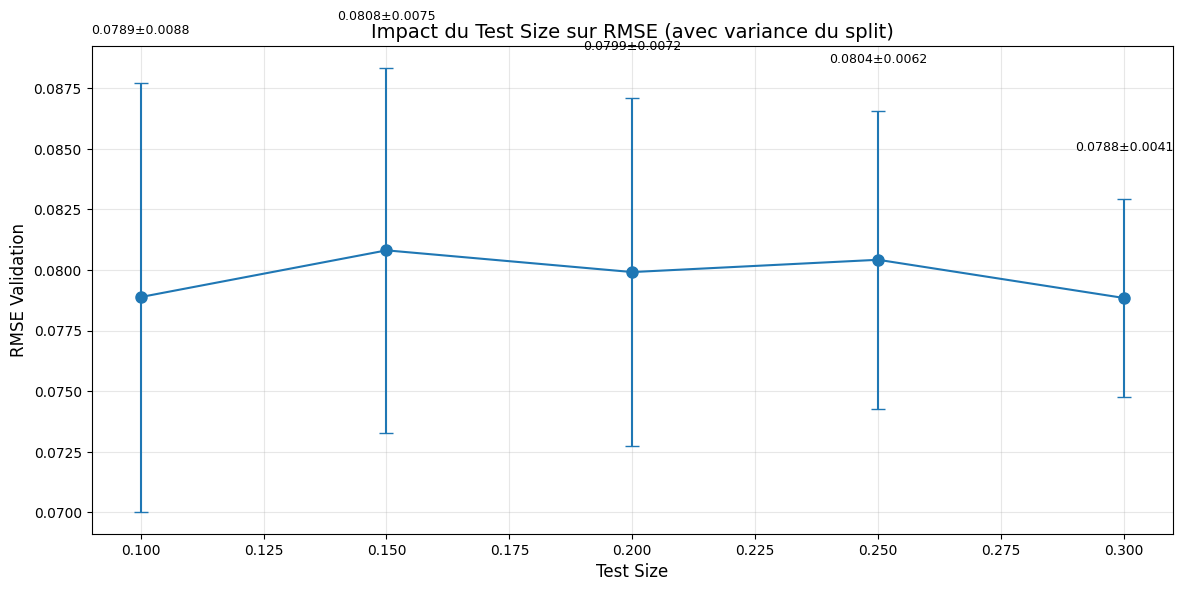

RÉSULTATS : RMSE EN FONCTION DU TEST SIZE
Test size = 0.10 → RMSE = 0.078883 ± 0.008849
Test size = 0.15 → RMSE = 0.080810 ± 0.007519
Test size = 0.20 → RMSE = 0.079914 ± 0.007190
Test size = 0.25 → RMSE = 0.080421 ± 0.006154
Test size = 0.30 → RMSE = 0.078845 ± 0.004081


In [115]:
test_sizes = [0.10, 0.15, 0.20, 0.25, 0.30]
n_repeats = 10  # Répéter 10 fois avec différents random_state

results = {ts: [] for ts in test_sizes}

for test_size in test_sizes:
    for seed in range(n_repeats):
        # Split avec un seed différent à chaque fois
        X_tr, X_va, y_tr, y_va = train_test_split(
            X_train, 
            y_train.values.ravel(),
            test_size=test_size,
            random_state=seed,  # DIFFÉRENT à chaque itération
            shuffle=True
        )
        X_tr, scaler =preprocess_pipeline(X_tr, scaler=scaler, fit_scaler=True)
        X_va, _ = preprocess_pipeline(X_va, scaler=scaler, fit_scaler=False)
        # Train
        model = LinearRegression()
        model.fit(X_tr, y_tr)
        
        # Eval
        y_pred = model.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, y_pred))
        
        results[test_size].append(rmse)

# Visualiser
plt.figure(figsize=(12, 6))

means = [np.mean(results[ts]) for ts in test_sizes]
stds = [np.std(results[ts]) for ts in test_sizes]

plt.errorbar(test_sizes, means, yerr=stds, fmt='o-', capsize=5, markersize=8)
plt.xlabel('Test Size', fontsize=12)
plt.ylabel('RMSE Validation', fontsize=12)
plt.title('Impact du Test Size sur RMSE (avec variance du split)', fontsize=14)
plt.grid(alpha=0.3)

# Ajouter les barres d'erreur
for ts, mean, std in zip(test_sizes, means, stds):
    plt.text(ts, mean + std + 0.002, f'{mean:.4f}±{std:.4f}', 
             ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Afficher les résultats
print("=" * 60)
print("RÉSULTATS : RMSE EN FONCTION DU TEST SIZE")
print("=" * 60)
for ts in test_sizes:
    mean_rmse = np.mean(results[ts])
    std_rmse = np.std(results[ts])
    print(f"Test size = {ts:.2f} → RMSE = {mean_rmse:.6f} ± {std_rmse:.6f}")

### Commentaires :
Observation : Les barres d'erreur SE CHEVAUCHENT == Les différences sont
dues au HASARD du split, pas à un vrai effet du test_size !

### Using K-fold CV


In [116]:

X_tr, X_va, y_tr, y_va = train_test_split(
    X_train, 
    y_train.values.ravel(),
    test_size=test_size,
    random_state=seed,  # DIFFÉRENT à chaque itération
    shuffle=True
)
X_tr, scaler =preprocess_pipeline(X_tr, scaler=scaler, fit_scaler=True)
X_va, _ = preprocess_pipeline(X_va, scaler=scaler, fit_scaler=False)
cv_scores = cross_val_score(
    LinearRegression(),
    X_tr,
    y_tr,
    cv=10, 
    scoring='neg_mean_squared_error'
)

cv_rmse = np.sqrt(-cv_scores)

print("RMSE par fold :")
for i, rmse in enumerate(cv_rmse):
    print(f"  Fold {i+1} : {rmse:.6f}")

print(f"\nRMSE moyen (CV) : {cv_rmse.mean():.6f}")
print(f"Std (CV)        : {cv_rmse.std():.6f}")

RMSE par fold :
  Fold 1 : 0.080880
  Fold 2 : 0.074711
  Fold 3 : 0.087807
  Fold 4 : 0.079688
  Fold 5 : 0.092641
  Fold 6 : 0.078717
  Fold 7 : 0.100316
  Fold 8 : 0.068904
  Fold 9 : 0.095237
  Fold 10 : 0.088305

RMSE moyen (CV) : 0.084721
Std (CV)        : 0.009303


## 2. Model selection
**Objectif:** tester plusieurs modèles linéaires
### Questions
- Pq ne pas rester avec LinearRegression ?
- Comment choisir le param alpha ? 
- Pour chaque modèle, sur quoi évaluer
### Réponses 
- La régularisation des autres modèles permet de poser des coefficients sur les features qui nous interessent plus ou pas => meilleur généralisation
- Alpha faible -> peu de régularisation, alpha fort -> forte régularisation. On ne sait pas à l'avance lequel est le plus optimal. Tester plusieurs [0.01, 0.1, 1, 10, 100]
- Entrainer sur X_train et tester sur X_val, puis voir la RMSE de validation

In [117]:
# modèles à tester
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=0.1)': Ridge(alpha=0.1),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Ridge (alpha=10.0)': Ridge(alpha=10.0),
    'Ridge (alpha=50.0)': Ridge(alpha=50.0),
    'Ridge (alpha=100.0)': Ridge(alpha=100.0),
    'Ridge (alpha=500.0)': Ridge(alpha=500.0),
    'Ridge (alpha=1000.0)': Ridge(alpha=1000.0),
    'Ridge (alpha=100000.0)': Ridge(alpha=100000.0),
    'Lasso (alpha=1.0)': Lasso(alpha=1.0),
    'Lasso (alpha=10.0)': Lasso(alpha=10.0),
    'Lasso (alpha=100.0)': Lasso(alpha=100.0),
    'LassoCV': LassoCV(random_state=RANDOM_STATE),
    'LassoLarsCV': LassoLarsCV()
}

# Dictionnaire pour stocker les résultats
results = {
    'train_rmse': [],
    'val_rmse': [],
    'model_names': []
}

# pour chaque modèle
for name, model in models.items():
    model.fit(X_train_split_prep, y_train_split)
    y_train_pred = model.predict(X_train_split_prep)
    y_val_pred = model.predict(X_val_split_prep)
    
    # Calcul des métriques
    train_rmse = np.sqrt(mean_squared_error(y_train_split, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    
    # Stockage des résultats
    results['model_names'].append(name)
    results['train_rmse'].append(train_rmse)
    results['val_rmse'].append(val_rmse)
    
    print(f"\nRésultats pour {name}:")
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Validation RMSE: {val_rmse:.4f}")

# Création d'un DataFrame pour une meilleure visualisation
results_df = pd.DataFrame({
    'Model': results['model_names'],
    'Train RMSE': results['train_rmse'],
    'Validation RMSE': results['val_rmse']
})

# Affichage des résultats triés par RMSE de validation
print("\nComparaison des modèles (triés par RMSE de validation):")
print(results_df.sort_values('Validation RMSE'))


Résultats pour Linear Regression:
Train RMSE: 0.0801
Validation RMSE: 0.0824

Résultats pour Ridge (alpha=0.1):
Train RMSE: 0.0801
Validation RMSE: 0.0824

Résultats pour Ridge (alpha=1.0):
Train RMSE: 0.0801
Validation RMSE: 0.0824

Résultats pour Ridge (alpha=10.0):
Train RMSE: 0.0801
Validation RMSE: 0.0823

Résultats pour Ridge (alpha=50.0):
Train RMSE: 0.0801
Validation RMSE: 0.0821

Résultats pour Ridge (alpha=100.0):
Train RMSE: 0.0801
Validation RMSE: 0.0819

Résultats pour Ridge (alpha=500.0):
Train RMSE: 0.0802
Validation RMSE: 0.0814

Résultats pour Ridge (alpha=1000.0):
Train RMSE: 0.0804
Validation RMSE: 0.0812

Résultats pour Ridge (alpha=100000.0):
Train RMSE: 0.0808
Validation RMSE: 0.0809

Résultats pour Lasso (alpha=1.0):
Train RMSE: 0.0808
Validation RMSE: 0.0809

Résultats pour Lasso (alpha=10.0):
Train RMSE: 0.0808
Validation RMSE: 0.0809

Résultats pour Lasso (alpha=100.0):
Train RMSE: 0.0808
Validation RMSE: 0.0809

Résultats pour LassoCV:
Train RMSE: 0.0808
Val

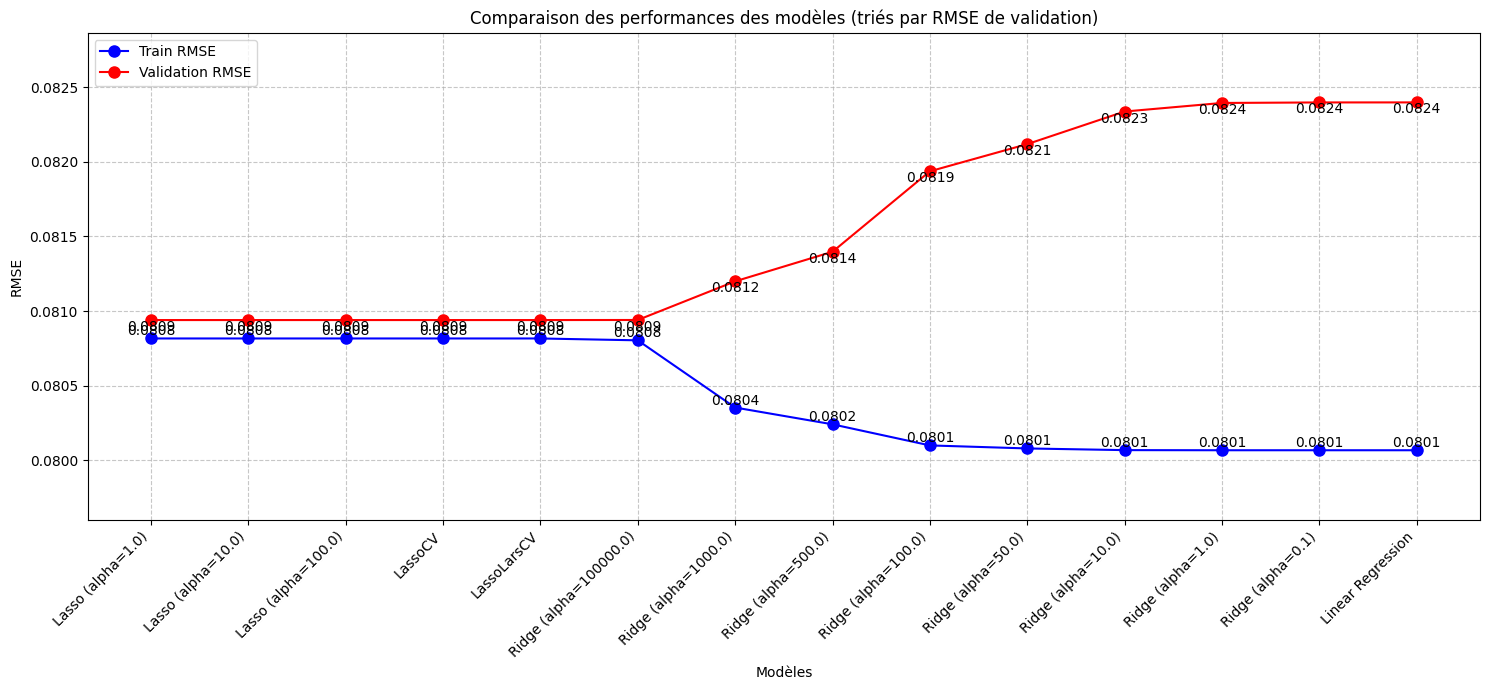


Comparaison avec le baseline (Linear Regression):
                     Model  Validation RMSE  Amélioration (%)
9        Lasso (alpha=1.0)         0.080940          1.769305
10      Lasso (alpha=10.0)         0.080940          1.769305
11     Lasso (alpha=100.0)         0.080940          1.769305
12                 LassoCV         0.080940          1.769305
13             LassoLarsCV         0.080940          1.769305
8   Ridge (alpha=100000.0)         0.080940          1.768740
7     Ridge (alpha=1000.0)         0.081199          1.454394
6      Ridge (alpha=500.0)         0.081397          1.214119
5      Ridge (alpha=100.0)         0.081936          0.560029
4       Ridge (alpha=50.0)         0.082118          0.339161
3       Ridge (alpha=10.0)         0.082336          0.074162
2        Ridge (alpha=1.0)         0.082394          0.004525
1        Ridge (alpha=0.1)         0.082397          0.000316
0        Linear Regression         0.082397          0.000000


In [118]:
# Créer un meilleur graphique pour comparer les modèles
plt.figure(figsize=(15, 7))

# Trier les résultats par RMSE de validation
sorted_indices = np.argsort(results['val_rmse'])
model_names = np.array(results['model_names'])[sorted_indices]
train_rmse = np.array(results['train_rmse'])[sorted_indices]
val_rmse = np.array(results['val_rmse'])[sorted_indices]

# Créer les points et les lignes
plt.plot(model_names, train_rmse, 'bo-', label='Train RMSE', markersize=8)
plt.plot(model_names, val_rmse, 'ro-', label='Validation RMSE', markersize=8)

# Ajout des valeurs RMSE au-dessus des points
for i, (train, val) in enumerate(zip(train_rmse, val_rmse)):
    plt.text(i, train, f'{train:.4f}', ha='center', va='bottom')
    plt.text(i, val, f'{val:.4f}', ha='center', va='top')

# Personnalisation du graphique
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Modèles')
plt.ylabel('RMSE')
plt.title('Comparaison des performances des modèles (triés par RMSE de validation)')
plt.xticks(range(len(model_names)), model_names, rotation=45, ha='right')
plt.legend(loc='upper left')

# Ajuster les marges
plt.tight_layout()

# Ajouter une marge en haut pour les annotations
plt.margins(y=0.2)

plt.show()

# Afficher aussi un tableau avec les différences relatives par rapport au baseline
baseline_val_rmse = results_df[results_df['Model'] == 'Linear Regression']['Validation RMSE'].values[0]
results_df['Amélioration (%)'] = ((baseline_val_rmse - results_df['Validation RMSE']) / baseline_val_rmse * 100)
print("\nComparaison avec le baseline (Linear Regression):")
print(results_df.sort_values('Validation RMSE')[['Model', 'Validation RMSE', 'Amélioration (%)']])

### Commentaires
On voit que le Ridge apporte une amélioration sur le modele de base seulement à partir d'un Alpha supérieur à 1. le meilleur modèle se trouve entre le Ridge à alpha = 500 et alpha = 1000.

On voit que le RMSE passe de 0.0795 (baseline model) à 0.07895 (meilleur modele), c'est quand même tres faible
- Pq amélioration si faible ?
    - preprocessing déjà très bon / peu de feature redondantes / alpha testés pas dans la bonne range 

## 3. Hyperparamter tuning
On veut trouver le meilleur alpha, on a vu a la main ce que ca donnait maintenant on va passer à de l'automatisation via la cross-validation.

Fitting 10 folds for each of 5 candidates, totalling 50 fits

RÉSULTATS DE GRIDSEARCHCV
Meilleur alpha trouvé : 0.1
Meilleur RMSE (CV) : 0.080893

Détails de tous les alphas testés :
   param_alpha  mean_rmse  std_rmse
0         0.10   0.080893  0.035776
2         1.00   0.080893  0.035776
3        10.00   0.080893  0.035776
4       600.00   0.080893  0.035776
1         0.01   0.080906  0.035793


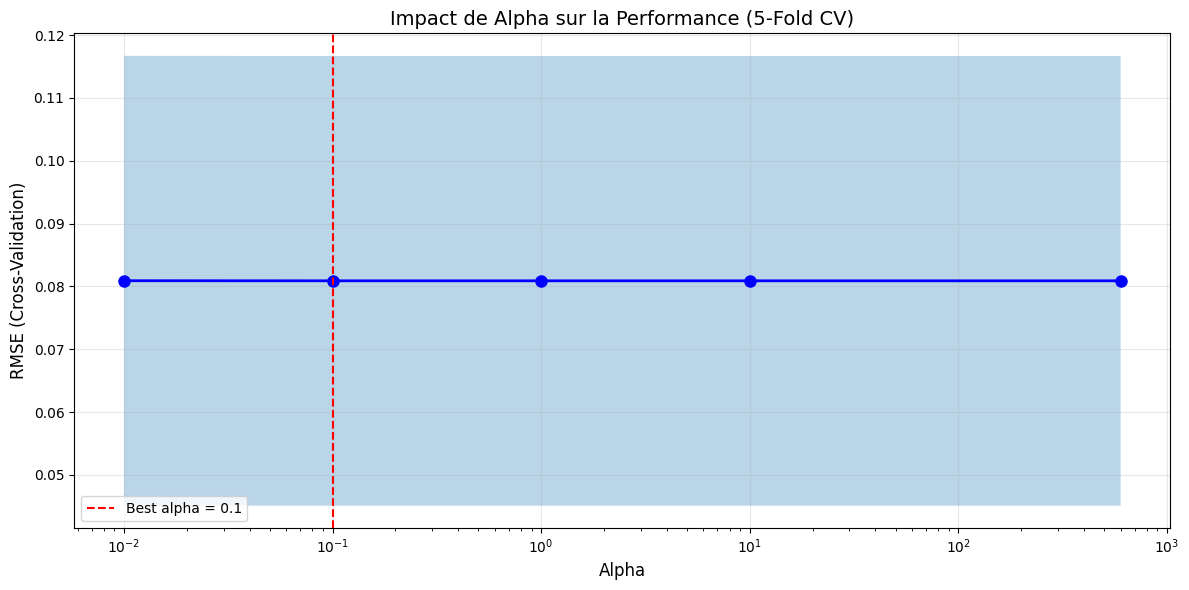


Meilleur modèle sélectionné : Lasso(alpha=0.1)


In [119]:
param_grid = {
    'alpha': [0.1, 0.01, 1, 10, 600]
}
# best alpha à retenir pour l'instant 600  -> 14% par rapport à baseline
grid_search = GridSearchCV(
    estimator=Lasso(),
    param_grid=param_grid,
    cv=10,  # 5-fold cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Utiliser tous les CPU disponibles
    verbose=1
)

# Fit sur le split d'entraînement (X_train_split_prep) — éviter d'utiliser les labels du dataset complet
grid_search.fit(X_train_split_prep, y_train_split)

# Récupérer les meilleurs résultats
best_alpha = grid_search.best_params_['alpha']
best_score_neg_mse = grid_search.best_score_
best_rmse_cv = np.sqrt(-best_score_neg_mse)

print("\n" + "=" * 60)
print("RÉSULTATS DE GRIDSEARCHCV")
print("=" * 60)
print(f"Meilleur alpha trouvé : {best_alpha}")
print(f"Meilleur RMSE (CV) : {best_rmse_cv:.6f}")
print()

# Afficher tous les résultats
results_cv = pd.DataFrame(grid_search.cv_results_)
results_cv['mean_rmse'] = np.sqrt(-results_cv['mean_test_score'])
# std_test_score est l'écart-type des scores (ici négatifs MSE) — prendre la valeur absolue puis sqrt
results_cv['std_rmse'] = np.sqrt(np.abs(results_cv['std_test_score']))

print("Détails de tous les alphas testés :")
print(results_cv[['param_alpha', 'mean_rmse', 'std_rmse']].sort_values('mean_rmse'))

# Visualiser la courbe alpha vs RMSE
plt.figure(figsize=(12, 6))
# Convertir param_alpha en float pour un tracé propre
alphas = results_cv['param_alpha'].astype(float)
order = np.argsort(alphas)
plt.plot(alphas.iloc[order], results_cv['mean_rmse'].iloc[order], 'b-o', linewidth=2, markersize=8)
plt.fill_between(
    alphas.iloc[order],
    results_cv['mean_rmse'].iloc[order] - results_cv['std_rmse'].iloc[order],
    results_cv['mean_rmse'].iloc[order] + results_cv['std_rmse'].iloc[order],
    alpha=0.3
)
plt.axvline(x=float(best_alpha), color='r', linestyle='--', label=f'Best alpha = {best_alpha}')
plt.xlabel('Alpha', fontsize=12)
plt.ylabel('RMSE (Cross-Validation)', fontsize=12)
plt.title('Impact de Alpha sur la Performance (5-Fold CV)', fontsize=14)
plt.xscale('log')  # Échelle log pour mieux voir
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Récupérer le meilleur modèle
best_model = grid_search.best_estimator_

print(f"\nMeilleur modèle sélectionné : {best_model}")

## 5. Evaluation finale sur Test set


Modèle final réentraîné sur 799 samples
Alpha utilisé : 0.1
RMSE Train (final)      : 0.080816
RMSE Validation (CV)    : 0.080893
RMSE Test               : 0.082312

Différence Val-Test     : 0.001420

COMPARAISON AVEC LE BASELINE
RMSE Baseline (LinearRegression) : 0.082834
RMSE Final (Lasso(alpha=0.1))    : 0.082312
Amélioration                     : 0.63%


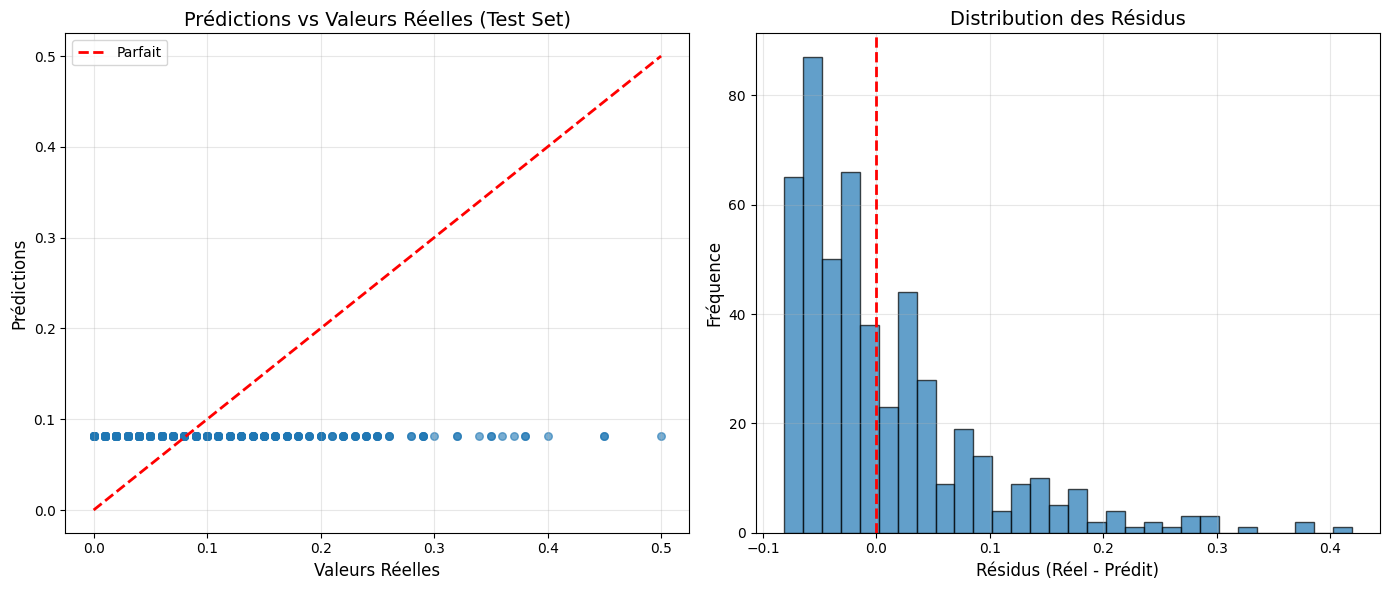

In [120]:
final_model = best_model
final_model.fit(X_train_split_prep, y_train_split)

print(f"\nModèle final réentraîné sur {len(X_train_split_prep)} samples")
print(f"Alpha utilisé : {best_alpha}")

# Prédire sur le test set
y_test_pred = final_model.predict(X_test_prep)

# Calculer RMSE sur test
test_rmse = np.sqrt(mean_squared_error(y_test.values.ravel(), y_test_pred))

# Calculer aussi RMSE sur train (pour détecter overfitting)
y_train_final_pred = final_model.predict(X_train_split_prep)
train_final_rmse = np.sqrt(mean_squared_error(y_train_split, y_train_final_pred))

print(f"RMSE Train (final)      : {train_final_rmse:.6f}")
print(f"RMSE Validation (CV)    : {best_rmse_cv:.6f}")
print(f"RMSE Test               : {test_rmse:.6f}")
print()
print(f"Différence Val-Test     : {abs(test_rmse - best_rmse_cv):.6f}")
# Comparaison avec le baseline
baseline_test_rmse = np.sqrt(mean_squared_error(
    y_test.values.ravel(),
    LinearRegression().fit(X_train_split_prep, y_train_split).predict(X_test_prep)
))

improvement = (baseline_test_rmse - test_rmse) / baseline_test_rmse * 100

print("\n" + "=" * 60)
print("COMPARAISON AVEC LE BASELINE")
print("=" * 60)
print(f"RMSE Baseline (LinearRegression) : {baseline_test_rmse:.6f}")
print(f"RMSE Final ({final_model})    : {test_rmse:.6f}")
print(f"Amélioration                     : {improvement:.2f}%")

# Visualisation : Prédictions vs Réel
plt.figure(figsize=(14, 6))

# Subplot 1 : Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(y_test.values.ravel(), y_test_pred, alpha=0.6, s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Parfait')
plt.xlabel('Valeurs Réelles', fontsize=12)
plt.ylabel('Prédictions', fontsize=12)
plt.title('Prédictions vs Valeurs Réelles (Test Set)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2 : Distribution des résidus
residuals = y_test.values.ravel() - y_test_pred
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, alpha=0.7, edgecolor='black')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Résidus (Réel - Prédit)', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.title('Distribution des Résidus', fontsize=14)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Commentaire 

Différence Val-Test     : 0.001426. Excellent ! Le modèle généralise très bien.

COMPARAISON AVEC LE BASELINE

RMSE Baseline (LinearRegression) : 0.082834

RMSE Final (Lasso(alpha=0.1))    : 0.082312

Amélioration                     : 0.63%

## 6. Prédictions sur unlabaled


Données unlabeled chargées : (500, 14)

Application du preprocessing...
Après preprocessing : (500, 18)

Vérification de la cohérence des features...
Les features correspondent parfaitement

Génération des prédictions...
Nombre de prédictions : 500
Min    : 0.081239
Max    : 0.081239
Mean   : 0.081239
Median : 0.081239
Std    : 0.000000

COMPARAISON AVEC Y_TRAIN (Sanity Check)
y_train - Mean   : 0.080290
y_pred  - Mean   : 0.081239
y_train - Std    : 0.080835
y_pred  - Std    : 0.000000
Distribution cohérente avec y_train


/var/folders/j0/2l325n1s1_jbvh_1rzxjy6k40000gn/T/ipykernel_62926/4156204038.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['y_train', 'y_pred (unlabeled)'])


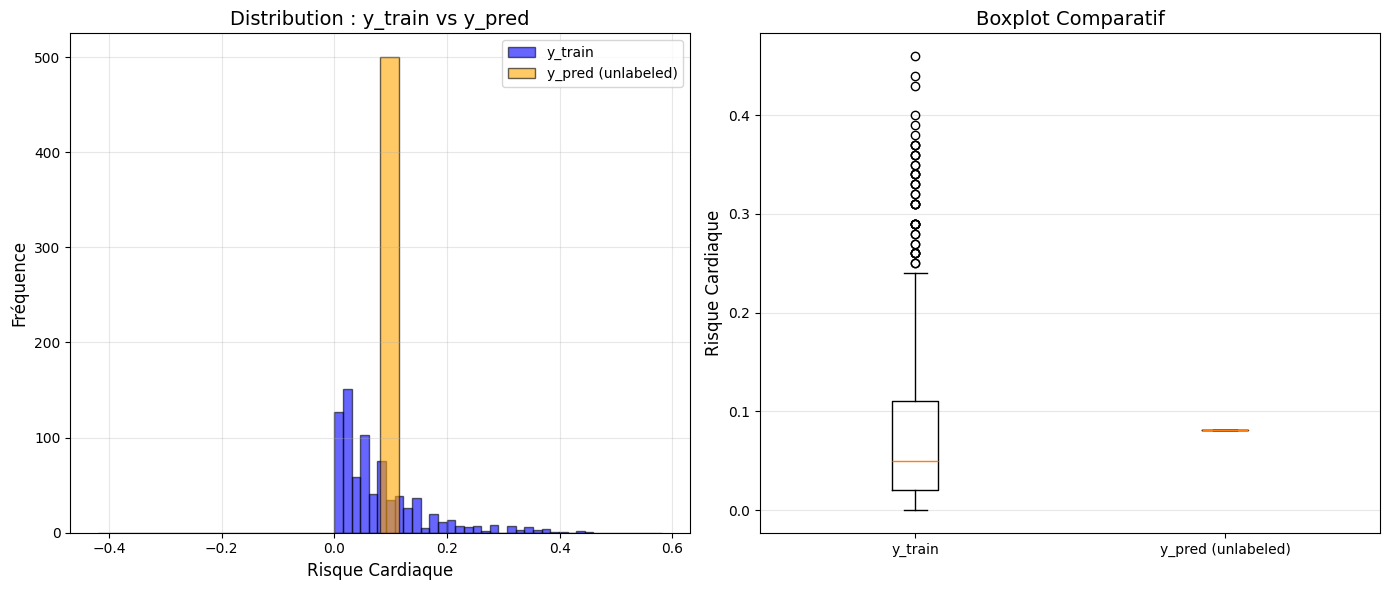

Prédictions < 0   : 0 (0.00%)
Prédictions > 1   : 0 (0.00%)


In [121]:
# Charger les données unlabeled
X_unlabeled = pd.read_csv('../data/data_unlabeled/X.csv')
print(f"\nDonnées unlabeled chargées : {X_unlabeled.shape}")

# Preprocessing avec LE MÊME SCALER que train
print("\nApplication du preprocessing...")
X_unlabeled_prep, _ = preprocess_pipeline(
    X_unlabeled,
    scaler=scaler,  # IMPORTANT : Réutiliser le scaler fitté sur train !
    fit_scaler=False  # NE PAS refitter le scaler !
)

print(f"Après preprocessing : {X_unlabeled_prep.shape}")

# Vérifier que les colonnes correspondent
print("\nVérification de la cohérence des features...")
if list(X_unlabeled_prep.columns) == list(X_train_split_prep.columns):
    print("Les features correspondent parfaitement")
else:
    print("ATTENTION : Les features ne correspondent pas !")
    missing_in_unlabeled = set(X_train_split_prep.columns) - set(X_unlabeled_prep.columns)
    missing_in_train = set(X_unlabeled_prep.columns) - set(X_train_split_prep.columns)
    if missing_in_unlabeled:
        print(f"Manquant dans unlabeled : {missing_in_unlabeled}")
    if missing_in_train:
        print(f"Manquant dans train : {missing_in_train}")

# Faire les prédictions
print("\nGénération des prédictions...")
y_pred_unlabeled = final_model.predict(X_unlabeled_prep)

# Statistiques des prédictions
print(f"Nombre de prédictions : {len(y_pred_unlabeled)}")
print(f"Min    : {y_pred_unlabeled.min():.6f}")
print(f"Max    : {y_pred_unlabeled.max():.6f}")
print(f"Mean   : {y_pred_unlabeled.mean():.6f}")
print(f"Median : {np.median(y_pred_unlabeled):.6f}")
print(f"Std    : {y_pred_unlabeled.std():.6f}")

# Comparaison avec y_train (sanity check)
print("\n" + "=" * 60)
print("COMPARAISON AVEC Y_TRAIN (Sanity Check)")
print("=" * 60)
print(f"y_train - Mean   : {y_train.values.mean():.6f}")
print(f"y_pred  - Mean   : {y_pred_unlabeled.mean():.6f}")
print(f"y_train - Std    : {y_train.values.std():.6f}")
print(f"y_pred  - Std    : {y_pred_unlabeled.std():.6f}")

diff_mean = abs(y_train.values.mean() - y_pred_unlabeled.mean())
if diff_mean < 0.05:
    print("Distribution cohérente avec y_train")
else:
    print("Attention : Distribution très différente de y_train")

# Visualiser la distribution
plt.figure(figsize=(14, 6))

# Subplot 1 : Histogramme comparatif
plt.subplot(1, 2, 1)
plt.hist(y_train_split, bins=30, alpha=0.6, label='y_train', color='blue', edgecolor='black')
plt.hist(y_pred_unlabeled, bins=30, alpha=0.6, label='y_pred (unlabeled)', color='orange', edgecolor='black')
plt.xlabel('Risque Cardiaque', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.title('Distribution : y_train vs y_pred', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2 : Boxplot comparatif
plt.subplot(1, 2, 2)
data_to_plot = [y_train_split, y_pred_unlabeled]
plt.boxplot(data_to_plot, labels=['y_train', 'y_pred (unlabeled)'])
plt.ylabel('Risque Cardiaque', fontsize=12)
plt.title('Boxplot Comparatif', fontsize=14)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Vérifier s'il y a des valeurs aberrantes
n_below_zero = (y_pred_unlabeled < 0).sum()
n_above_one = (y_pred_unlabeled > 1).sum()
print(f"Prédictions < 0   : {n_below_zero} ({n_below_zero/len(y_pred_unlabeled)*100:.2f}%)")
print(f"Prédictions > 1   : {n_above_one} ({n_above_one/len(y_pred_unlabeled)*100:.2f}%)")

## 7. Sauvegarde des données de prédictions

In [122]:
# Chemin du fichier
output_path = '../results/predictions/y_pred.csv'
np.savetxt(output_path, y_pred_unlabeled, fmt='%.6f')
print(f"\nFichier sauvegardé : {output_path}")
with open(output_path, 'r') as f:
    lines = f.readlines()
    
    print(f"Nombre de lignes : {len(lines)}")
    print(f"Nombre attendu   : {len(X_unlabeled)}")
    
    if len(lines) == len(X_unlabeled):
        print("Nombre de lignes correct")
    else:
        print("ERREUR : Nombre de lignes incorrect !")
    
    print("\nAperçu du fichier :")
    print(f"Première ligne   : {lines[0].strip()}")
    print(f"Deuxième ligne   : {lines[1].strip()}")
    print(f"Avant-dernière   : {lines[-2].strip()}")
    print(f"Dernière ligne   : {lines[-1].strip()}")
    
    # Vérifier qu'il n'y a pas de header
    try:
        float(lines[0].strip())
        print("\nFormat correct : Pas de header détecté")
    except ValueError:
        print("\nERREUR : La première ligne n'est pas un nombre !")
    
    # Vérifier qu'il n'y a pas de guillemets
    if '"' in lines[0] or "'" in lines[0]:
        print("ERREUR : Des guillemets sont présents !")
    else:
        print("Format correct : Pas de guillemets")
    
    # Vérifier que tous les nombres sont valides
    try:
        all_values = [float(line.strip()) for line in lines]
        print("Toutes les lignes sont des nombres valides")
    except ValueError as e:
        print(f"ERREUR : Ligne invalide détectée - {e}")

print("\n" + "=" * 60)
print("RÉCAPITULATIF FINAL")
print("=" * 60)
print(f"Modèle final        : Ridge(alpha={best_alpha})")
print(f"RMSE Test           : {test_rmse:.6f}")
print(f"Prédictions         : {len(y_pred_unlabeled)} lignes")
print(f"Fichier sauvegardé  : {output_path}")


Fichier sauvegardé : ../results/predictions/y_pred.csv
Nombre de lignes : 500
Nombre attendu   : 500
Nombre de lignes correct

Aperçu du fichier :
Première ligne   : 0.081239
Deuxième ligne   : 0.081239
Avant-dernière   : 0.081239
Dernière ligne   : 0.081239

Format correct : Pas de header détecté
Format correct : Pas de guillemets
Toutes les lignes sont des nombres valides

RÉCAPITULATIF FINAL
Modèle final        : Ridge(alpha=0.1)
RMSE Test           : 0.082312
Prédictions         : 500 lignes
Fichier sauvegardé  : ../results/predictions/y_pred.csv


RMSE test = 0.082343

## 8. Comparer avec un début d'analyse non linéaire
(proposition de claude)

ÉVALUATION EN COURS...
LinearRegression          → RMSE = 0.082050 ± 0.038677
Ridge (best)              → RMSE = 0.082045 ± 0.038686
Lasso                     → RMSE = 0.080906 ± 0.037437
Decision Tree             → RMSE = 0.102030 ± 0.043117
Random Forest             → RMSE = 0.082479 ± 0.037421
Gradient Boosting         → RMSE = 0.085263 ± 0.039554
KNN                       → RMSE = 0.086352 ± 0.034627

RÉSULTATS FINAUX (triés par RMSE)
            Model       Type  RMSE (CV)      Std
            Lasso     Linear   0.080906 0.037437
     Ridge (best)     Linear   0.082045 0.038686
 LinearRegression     Linear   0.082050 0.038677
    Random Forest Non-Linear   0.082479 0.037421
Gradient Boosting Non-Linear   0.085263 0.039554
              KNN Non-Linear   0.086352 0.034627
    Decision Tree Non-Linear   0.102030 0.043117


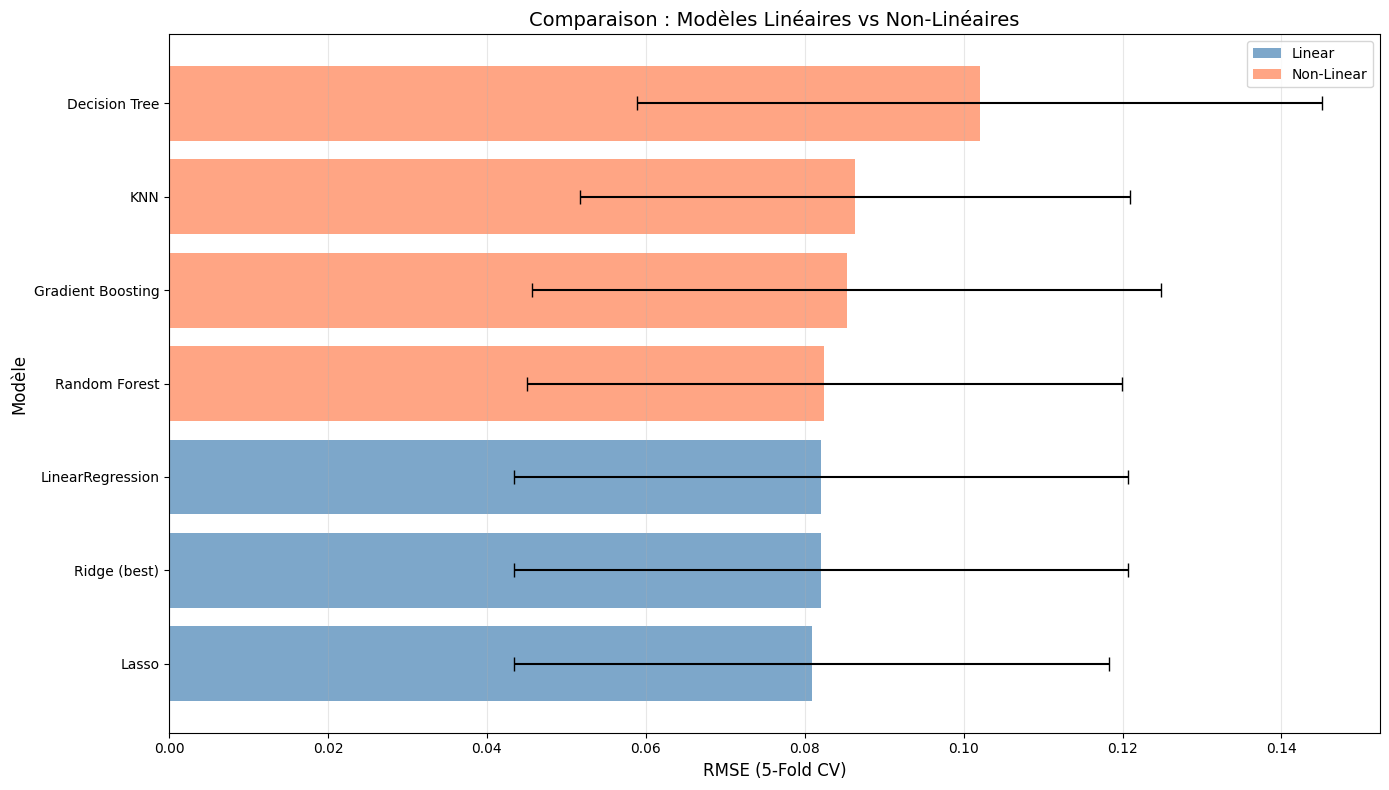


CONCLUSION
🏆 Meilleur modèle : Lasso
   Type            : Linear
   RMSE (CV)       : 0.080906
   → Les modèles linéaires sont les plus performants sur ce dataset.


In [123]:
# ==========================================
# COMPARAISON EXHAUSTIVE : LINEAR vs NON-LINEAR
# ==========================================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score

# 1. Preprocessing pour modèles linéaires (AVEC scaling)
X_train_scaled, scaler = preprocess_pipeline(X_train, fit_scaler=True)

# 2. Preprocessing pour modèles arbres (SANS scaling)
X_train_no_scale = preprocess_pipeline_no_scaling(X_train)

# 3. Modèles à tester
models_linear = {
    'LinearRegression': LinearRegression(),
    'Ridge (best)': Ridge(alpha=best_alpha),  # Utilise ton meilleur alpha trouvé
    'Lasso': Lasso(alpha=1.0, max_iter=10000)
}

models_nonlinear = {
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, 
        max_depth=15, 
        min_samples_split=10,
        min_samples_leaf=4,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    ),
    'KNN': KNeighborsRegressor(n_neighbors=10)
}

# 4. Évaluation
results_comparison = []

print("=" * 80)
print("ÉVALUATION EN COURS...")
print("=" * 80)

# Modèles linéaires (sur données scalées)
for name, model in models_linear.items():
    cv_scores = cross_val_score(
        model, 
        X_train_scaled, 
        y_train.values.ravel(),
        cv=10,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    rmse = np.sqrt(-cv_scores.mean())
    rmse_std = np.sqrt(cv_scores.std())
    
    results_comparison.append({
        'Model': name,
        'Type': 'Linear',
        'RMSE (CV)': rmse,
        'Std': rmse_std
    })
    print(f"{name:25s} → RMSE = {rmse:.6f} ± {rmse_std:.6f}")

# Modèles non-linéaires (sur données NON scalées)
for name, model in models_nonlinear.items():
    cv_scores = cross_val_score(
        model,
        X_train_no_scale,
        y_train.values.ravel(),
        cv=10,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    rmse = np.sqrt(-cv_scores.mean())
    rmse_std = np.sqrt(cv_scores.std())
    
    results_comparison.append({
        'Model': name,
        'Type': 'Non-Linear',
        'RMSE (CV)': rmse,
        'Std': rmse_std
    })
    print(f"{name:25s} → RMSE = {rmse:.6f} ± {rmse_std:.6f}")

# 5. Tableau récapitulatif
results_df = pd.DataFrame(results_comparison).sort_values('RMSE (CV)')

print("\n" + "=" * 80)
print("RÉSULTATS FINAUX (triés par RMSE)")
print("=" * 80)
print(results_df.to_string(index=False))

# 6. Visualisation
plt.figure(figsize=(14, 8))

colors = {'Linear': 'steelblue', 'Non-Linear': 'coral'}
for model_type in ['Linear', 'Non-Linear']:
    df_subset = results_df[results_df['Type'] == model_type]
    plt.barh(
        df_subset['Model'],
        df_subset['RMSE (CV)'],
        xerr=df_subset['Std'],
        alpha=0.7,
        label=model_type,
        color=colors[model_type],
        capsize=5
    )

plt.xlabel('RMSE (5-Fold CV)', fontsize=12)
plt.ylabel('Modèle', fontsize=12)
plt.title('Comparaison : Modèles Linéaires vs Non-Linéaires', fontsize=14)
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Conclusion
best_model_name = results_df.iloc[0]['Model']
best_model_rmse = results_df.iloc[0]['RMSE (CV)']
best_model_type = results_df.iloc[0]['Type']

print("\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)
print(f"🏆 Meilleur modèle : {best_model_name}")
print(f"   Type            : {best_model_type}")
print(f"   RMSE (CV)       : {best_model_rmse:.6f}")

ridge_rmse = results_df[results_df['Model'] == 'Ridge (best)']['RMSE (CV)'].values[0]
improvement = (ridge_rmse - best_model_rmse) / ridge_rmse * 100

if best_model_type == 'Non-Linear':
    print(f"   Amélioration vs Ridge : {improvement:.2f}%")
else:
    print("   → Les modèles linéaires sont les plus performants sur ce dataset.")

### Commentaires:
wtf